<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
<br>汉化的库: <a href="https://github.com/GoatCsu/CN-LLMs-from-scratch.git">https://github.com/GoatCsu/CN-LLMs-from-scratch.git</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>


# 第五章: 在无标签数据集上预训练

In [7]:
from importlib.metadata import version, PackageNotFoundError

pkgs = ["matplotlib", 
        "numpy", 
        "tiktoken", 
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
       ]
for p in pkgs:
    try:
        print(f"{p} version: {version(p)}")
    except PackageNotFoundError:
        print(f"{p} version: 未安装")

matplotlib version: 3.10.9
numpy version: 2.4.6
tiktoken version: 0.13.0
torch version: 2.12.0
tensorflow version: 2.21.0


- 在本章中，我们将实现循环训练和基本模型评价的代码，用于预训练大语言模型。
- 在本章的最后，我们还将从 OpenAI 加载公开可用的预训练权重到我们的模型中。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/chapter-overview.webp" width=500px>

- 本章节涉及的主题如下所示

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model--0.webp" width=400px>

## 5.1 评估文本生成大模型

- 本节开始时，我们简要回顾了如何使用上一章的代码初始化 GPT 模型。
- 然后，我们讨论了大语言模型的基本评估指标。
- 最后，在本节中，我们将这些评估指标应用于训练和验证数据集。

### 5.1.1 用GPT来生成文本

- 我们首先与前几章一样初始化GPT

In [8]:
import torch
from previous_chapters import GPTModel

# GPT-124M 模型的配置参数
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 词汇表大小（对应GPT-2的50257个token）
    "context_length": 256,  # 上下文长度（这里缩短为256，原版GPT-2为1024）
    "emb_dim": 768,         # 词嵌入维度（每个token的向量长度）
    "n_heads": 12,          # 注意力头的数量（多头注意力机制的头数）
    "n_layers": 12,         # Transformer层的数量（解码器堆叠的层数）
    "drop_rate": 0.1,       # Dropout层的随机失活概率（防止过拟合）
    "qkv_bias": False       # Query-Key-Value注意力层是否使用偏置项
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();

- 我们在上述代码中使用了 0.1 的 dropout 率，但如今训练大语言模型时通常不使用 dropout。
- 现代的大语言模型不在 `nn.Linear` 层的查询、键和值矩阵中使用偏置向量（与早期的 GPT 模型不同），而是通过设置 `"qkv_bias": False` 实现。
- 我们将上下文长度（`context_length`）减少到仅 256 个 token，以减少训练模型时的计算资源需求，而原始的 1.24 亿参数的 GPT-2 模型使用了 1024 个token。
  - 这是为了让更多读者可以在他们的笔记本电脑上运行并跟随代码示例。
  - 然而，您可以自由将 `context_length` 增加到 1024 个 token（这不需要更改任何代码）。
  - 我们稍后也将从预训练权重中加载一个具有 1024 `context_length` 的模型。

- 接下来，我们使用上一章中的 `generate_text_simple` 函数生成文本。
- 此外，我们定义了两个便利函数，`text_to_token_ids` 和 `token_ids_to_text`，用于在 token ID 和文本表示之间进行转换，这两个函数将在本章中多次使用。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/gpt-process.webp" width=500px>

In [9]:
import tiktoken
from previous_chapters import generate_text_simple

# 把 文本/ID 的转换、tiktoken列表/model张量的转换、维度的转换，封装成两个函数
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})  # 允许识别特殊 token
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]  # 256
)
# 把生成的 Token ID 张量还原成文本，打印出来
print("输出文本:\n", token_ids_to_text(token_ids, tokenizer))

输出文本:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


- 如上所示，由于模型尚未训练，它生成的文本并不理想。
- 我们如何衡量或设定“好文本”的标准，并将其转化为数值，以便在训练过程中进行跟踪？
- 下一小节介绍了计算生成输出的损失指标的度量标准，我们可以用它来衡量训练进度。
- 后续关于微调大语言模型的章节还将介绍其他衡量模型质量的方法。

### 5.1.2 计算文本生成的损失：交叉熵(cross- entropy)和困惑度(perplexity)

- 假设我们有一个 `inputs` 张量，其中包含 2 个训练示例（行）的 token ID。
- 与 `inputs` 对应，`targets` 包含我们希望模型生成的目标 token ID。
- 请注意，`targets` 是将 `inputs` 向右移动 1 个位置后的结果，正如我们在第二章实现数据加载器时所解释的那样。

In [16]:
# 输入 ID
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]
# 目标 ID （targets 是将 inputs 向右移动 1 个位置后的结果）
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

print(targets.shape)

torch.Size([2, 3])


- 将 `inputs` 输入给模型后，我们将得到 2 个输入示例的 logits 向量，每个输入示例包含 3 个token。
- 每个 token 都是一个 50,257 维的向量，对应于词汇表的大小。
- 通过应用 softmax 函数，我们可以将 logits 张量转换为一个相同维度的张量，其中包含概率得分。

In [17]:
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)

print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


- 下图展示了我们如何将概率得分转换为文本，示例使用了一个非常小的词汇表，这一内容已在上一章的结尾讨论过。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/proba-to-text.webp" width=500px>

- 如上一章所讨论的，我们可以应用 `argmax` 函数将概率得分转换为预测的 token ID。
- 上面的 softmax 函数为每个 token 生成了一个 50,257 维的向量；`argmax` 函数返回该向量中概率得分最高的位置，即给定 token 的预测 token ID。

- 由于我们有 2 个输入批次，每个批次包含 3 个 token，因此我们得到 2 行 3 列的预测 token ID：

In [19]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)  # 相当于用贪心算法给出最有可能的答案
print(token_ids.shape)
print("Token IDs:\n", token_ids)

torch.Size([2, 3, 1])
Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


- 如果解码这些 token，我们会发现它们与希望模型预测的 token (目标 token)有很大不同：

In [20]:
print(f"目标 batch 1: {token_ids_to_text(targets[0], tokenizer)}")

print(f"输出 batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")
print(token_ids_to_text(token_ids.flatten(), tokenizer))

目标 batch 1:  effort moves you
输出 batch 1:  Armed heNetflix
 Armed heNetflix pressuring empoweredfaith


- 这是因为模型还没有经过训练。
- 要训练模型，我们需要知道它与正确预测（目标）之间的差距有多大。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/proba-index.webp" width=500px>

- 对应于目标索引的 token 概率如下：

In [21]:
print('概率矩阵形状:',probas.shape)
print('正确目标的ID:\n',targets)

#text_idx = 0  # 取批次1样本
target_probas_1 = probas[0, [0,1,2], targets[0]]  # 批次索引、序列位置索引、目标 ID 索引，共同决定了要取的元素
print("Text 1 正确目标词概率:", target_probas_1)

#text_idx = 1  # 取批次2样本
target_probas_2 = probas[1, [0,1,2], targets[1]]
print("Text 2 正确目标词概率:", target_probas_2)

概率矩阵形状: torch.Size([2, 3, 50257])
正确目标的ID:
 tensor([[ 3626,  6100,   345],
        [ 1107,   588, 11311]])
Text 1 正确目标词概率: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2 正确目标词概率: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


- 我们希望最大化这些值，使它们的概率接近 1。
- 在数学优化中，最大化概率得分的对数比直接最大化概率得分更为简单；虽然这超出了本书的讨论范围，但我录制了一节更详细的讲座，您可以在这里查看：[L8.2 Logistic Regression Loss Function](https://www.youtube.com/watch?v=GxJe0DZvydM)。

In [24]:
print('拼接后:',torch.cat((target_probas_1, target_probas_2)))

# 把两个样本的目标 token 概率拼接起来，然后计算它们的对数
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print('log后:',log_probas)  # 用对数输出他最大的可能数值

拼接后: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05, 1.0337e-05, 5.6776e-05, 4.7559e-06])
log后: tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


- 接下来，我们计算平均对数概率：

In [25]:
# 对数概率平均值
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


- 目标是通过优化模型权重，使得平均对数概率尽可能大。
- 由于对数的性质，最大的可能值是 0，而我们当前距离 0 还有很大差距。

- 在深度学习中，通常的做法是最小化 "负" 的平均对数概率值，而不是最大化平均对数概率值；在我们的例子中，深度学习中我们会最小化 10.7722 使其接近 0，而不是最大化 -10.7722 使其接近 0。
- 值 -10.7722 的负数，即 10.7722，在深度学习中也被称为交叉熵损失（cross-entropy loss）。

In [27]:
# 负对数
neg_avg_log_probas = avg_log_probas * -1

print(neg_avg_log_probas)

tensor(10.7940)


- PyTorch 中的`cross_entropy` 已经能实现这些功能

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/cross-entropy.webp?123" width=400px>

- 在使用`cross_entropy` 之前, 我们可以看一下loggias跟target是怎样的

In [29]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


- 有了PyTorch 中的 `cross_entropy` 函数，我们希望通过在批次维度上合并这些张量来将其展平：

In [30]:
# PyTorch 自带的交叉熵损失函数 torch.nn.functional.cross_entropy，对输入的形状有严格要求：
# 输入 input（模型预测分数）：  必须是 2D 张量，形状为 [N, C]
# 输入 target（正确位置的索引）：必须是 1D 张量，形状为 [N]

logits_flat = logits.flatten(0, 1)  # 把 logits 的第 0 维（批次）和第 1 维（序列长度）合并成一个维度   [2,3,50257] → [6,50257]
targets_flat = targets.flatten()    # 把二维的目标 ID 张量，展平成 [6] 的一维张量                         [2,3] → [6]

print("Flattened logits:", logits_flat.shape)   # 「6 个样本、每个样本对应 50257 个词」
print("Flattened targets:", targets_flat.shape) # 按顺序把所有批次、所有位置的目标 ID 排成一个列表
print(targets_flat)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])
tensor([ 3626,  6100,   345,  1107,   588, 11311])


- 请注意，目标是 token ID，这些 ID 也代表我们希望最大化的 logits 张量中的索引位置。
- PyTorch 中的 `cross_entropy` 函数会自动处理对这些token索引的 softmax 和对数概率计算，确保它们被最大化。

In [33]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)  # （分数，索引）
print(loss)
# 大模型的训练，本质上就是把每一个词，当成一个 5 万分类的任务去做
# 这个函数内部自动做了三件事:
# 1.对 logits 做 softmax，转换成概率分布
# 2.对目标 token 的概率取对数（log(p)）
# 3.计算 -log(p) 的平均值，得到交叉熵损失

tensor(10.7940)


- 与交叉熵损失相关的一个概念是大语言模型的困惑度 (perplexity)。
- 困惑度就是交叉熵损失的指数值。

In [34]:
# 把交叉熵损失取自然指数，得到困惑度：模型对下一个 token 的 “平均候选词数量”
perplexity = torch.exp(loss)

print(perplexity)  # 困惑度范围：1~词汇表总数

tensor(48725.8203)


- 困惑度通常被认为更易解释，因为它可以理解为模型在每一步对词汇表大小的不确定性（在上面的例子中，这相当于 48,725 个单词或 token）。
- 换句话说，困惑度提供了一个衡量模型预测的概率分布与数据集中单词实际分布匹配程度的指标。
- 类似于损失值，较低的困惑度表示模型预测与实际分布的差距较小。

### 5.1.3 计算训练集和验证集的损失

- 我们使用一个相对较小的数据集来训练大语言模型（训练内容只有一个短篇故事）。
- 选择小故事的原因包括：
  - 无独立显卡的电脑也可以快速完成
  - 训练时间较短（以分钟计算，而非数周）
  - 我们使用了无版权文本，可以将其包含在这个 GitHub 仓库中，而不会违反任何使用权或显著增加仓库大小。

- 例如，Llama 2 7B 模型在 2 万亿 token 上训练时需要 184,320 个 GPU 小时（使用 A100 GPU）。
  - 截至本文撰写时，AWS 上 8xA100 云服务器的每小时成本约为 30 美元。
  - 因此，通过简单计算，训练这个 LLM 的成本为 184,320 / 8 * 30 美元 = 690,000 美元。

- 下面，我们使用了第二章中使用的同一数据集。

In [35]:
import os
import urllib.request  # Python 内置网络请求工具，用来从 URL 下载文件
# 经典读取数据操作
file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"
# 判断文件是否存在，不存在则下载
if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()  # 如果文件已存在，直接读取

- 首尾校验：通过前100个词与后100个词快速检查文本是否加载正常

In [36]:
# First 100 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [37]:
# Last 100 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [39]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("字符总数:", total_characters)
print("token总数:", total_tokens)
'''
H e l l o   w o r l d !  →  Hello  world !
              12 个字符   →   3 个 Token
不是去重，是合并！
Token = 字符的合并与打包
'''

字符总数: 20479
token总数: 5145


'\nH e l l o   w o r l d !  →  Hello  world !\n              12 个字符   →   3 个 Token\n不是去重，是合并！\nToken = 字符的合并与打包\n'

- 为了教学,我们选取了这个短文本作为样例

- 接下来，我们将数据集划分为训练集和验证集，并使用第二章中的data loader为大语言模型（LLM）训练准备数据。
- 出于可视化的目的，下图假设 `max_length=6`，但对于训练加载器，我们将 `max_length` 设置为 LLM 支持的上下文长度。
- 为了简化，下图仅展示了输入token：
    - 由于我们训练 LLM 预测文本中的下一个单词，因此目标 token 与输入 token 相同，只是目标 token 向右移动了一个位置。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/batching.webp" width=500px>

In [43]:
from previous_chapters import create_dataloader_v1  # 导入之前章实现的 create_dataloader_v1 函数

# 把文本数据按 9:1 切分成训练集和验证集
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]  # 取前 90%
val_data = text_data[split_idx:]    # 取后 10%

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,      # 训练文本数据
    batch_size=2,    # 批次大小
    max_length=GPT_CONFIG_124M["context_length"], # 每个样本的最大 token 数
    stride=GPT_CONFIG_124M["context_length"],     # 滑动窗口步长
    drop_last=True,  # 是否丢弃最后一批不足 batch_size 的数据
    shuffle=True,    # 是否打乱数据顺序
    num_workers=0    # 多进程加载数据（Windows系统下通常设为 0）
)

val_loader = create_dataloader_v1(
    val_data,        # 验证集文本
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False, # 不丢弃最后一批不足 batch_size 的数据，验证时要完整评估所有数据
    shuffle=False,   # 不打乱数据顺序，方便观察模型在数据上的连续预测效果
    num_workers=0
)
# 区别1：训练需要打乱防止过拟合，验证不需要
# 区别2：训练要稳定批次大小，验证要完整评估数据

In [44]:
# Sanity Check（数据量安全校验）
# 训练集的 token 总数，必须 ≥ 模型的上下文长度（256），否则连一个训练样本都切不出来
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("训练集的token数量不足，无法构建训练数据加载器。"
          "请尝试降低 `GPT_CONFIG_124M['context_length']`（上下文长度），"
          "或提高 `training_ratio`（训练集占比）")
# 验证集同理，token 总数也必须 ≥ 256
if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("验证集的token数量不足，无法构建验证数据加载器。"
          "请尝试降低 `GPT_CONFIG_124M['context_length']`（上下文长度），"
          "或降低 `training_ratio`（训练集占比），以增加验证集的token数量")

- 小的批处理数据集很适合用来小试牛刀
- 例如, Llama 27B就是用每次1024的批处理数据

- 另一种确认数据正常导入的方法如下

In [45]:
# 验证 DataLoader 是否正常工作，样本形状是否符合预期
# x：模型的输入 token 序列，形状是 [batch_size, context_length]
# y：模型的目标 token 序列（每个位置的下一个词），形状和 x 完全一样
print("Train loader:")
for x, y in train_loader:    # 4630 / 256 = 18个样本 （18×256 = 4608，剩下 22 个不足 256，被丢掉）
    print(x.shape, y.shape)  # 18 / 2 = 9个批次 （batch_size=2 → 每2个样本拼成1个批次）

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


- 还有一个方法来确认是否导入成功

In [48]:
# 遍历训练集和验证集的所有批次，统计实际参与训练的 token 总数，确认数据加载的完整性
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()   # 返回当前批次所有元素的总数：2×256=512，累加
                                          # PyTorch 张量的 .numel() 方法，会不管张量的形状和维度，直接返回所有元素的总数
val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


- 我们用了预分装函数来计算交叉熵
- 我们还调用另一个辅助函数，用于计算数据加载器中由用户指定的批次数Loss。

In [49]:
# 计算单个批次（batch）的交叉熵损失，是所有批次损失计算的基础单元
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)  # 把输入和目标张量移动到指定设备（CPU/GPU）
    logits = model(input_batch)  # 输入批次传给模型，得到模型的原始输出 logits    [2,256] → [2,256,50257]
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    # 批次和序列维度合并，变成 [2*256, 50257] = [512, 50257]  |  目标ID展平成一维，变成 [512]
    return loss  # 代表这个批次所有 token 的平均损失

# 批量计算数据加载器（DataLoader）中多个批次的平均损失，用来评估模型在整个数据集上的表现
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:  # 如果数据加载器是空的，返回 nan（不是数字），避免后续除以 0 错误
        return float("nan")
    elif num_batches is None:  # 如果没有手动指定 num_batches，就按数据加载器中所有的批次计算平均损失
        num_batches = len(data_loader)
    else:                      # 如果指定的批次数超过数据加载器中的总批次数，就取它和总批次数的最小值，防止指定的批次数超过实际存在的批次数，导致越界错误
        num_batches = min(num_batches, len(data_loader))
    # 遍历批次计算损失
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:  # 不超过手动指定的批次
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()  # item() 把 PyTorch 张量 → 变成普通 Python 数字
            # 可以避免显存泄漏，每个 loss 张量都会保留计算图，循环几千次后，显存直接占满卡死）
        else:
            break  # 如果超过了 num_batches，就 break 跳出循环，不再处理后面的批次

    return total_loss / num_batches  # 总损失除以批次数量，得到该num_batches个批次的平均损失

- 如果你的电脑有支持 CUDA 的 GPU，大预言模型将无需更改代码即可在 GPU 上进行训练。
- 通过 `device` 设置，我们确保数据加载到与大语言模型相同的设备上。

In [52]:
# 自动选择可用的计算设备（GPU/CPU）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)  # 把模型的所有参数和缓冲区都移动到device指定设备上，nn.Module类：model.to(device)是原地操作，不需要再写model = model.to(device)

torch.manual_seed(123)  # 固定随机种子，保证数据加载器的打乱顺序、模型初始化的随机状态都完全一致

with torch.no_grad():   # 上下文管理器，在这个代码块内，PyTorch 不会计算梯度，也不会构建计算图
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("训练集平均损失:", train_loss)
print("验证集平均损失:", val_loss)

训练集平均损失: 10.98758347829183
验证集平均损失: 10.981106758117676


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model-1.webp" width=400px>

## 5.2 训练大语言模型

- 在本节中，我们最终实现了用于训练大语言模型（LLM）的代码。
- 我们想要于一个简单的训练函数（如果您对通过更高级的技术增强此训练函数感兴趣，例如学习率预热(rate warmup)、余弦退火(cosine annealing)和梯度裁剪(gradient clipping)，请参阅[附录D](../../appendix-D/01_main-chapter-code)）。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/train-steps.webp" width=300px>

In [54]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    # 初始化三个空列表，用来记录训练过程中的训练损失、验证损失和已训练的 token 总数，方便后续画图
    train_losses, val_losses, track_tokens_seen = [], [], []
    # 统计从训练开始到现在，模型总共见过多少个 token | 总共训练了多少个批次（全局步数）
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):  # 外层循环：遍历训练轮数
        model.train()  # 切换到训练模式
        for input_batch, target_batch in train_loader:  # 内层循环：遍历每个批次
            optimizer.zero_grad()  # 清空上一个批次的梯度，防累加
            loss = calc_loss_batch(input_batch, target_batch, model, device)  # 计算当前批次的损失
            loss.backward()   # 反向传播，计算所有参数的梯度
            optimizer.step()  # 根据梯度更新所有权重
            tokens_seen += input_batch.numel()  # 累加当前批次的token总数（batch_size × context_length）
            global_step += 1  # 全局批次步数加1
            # 可选评估步骤
            if global_step % eval_freq == 0:  # 每隔eval_freq步，评估一次模型
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.     append(train_loss)    # 记录训练损失
                val_losses.       append(val_loss)      # 记录验证损失
                track_tokens_seen.append(tokens_seen)   # 记录已训练总token数量
                # 打印当前的 epoch、步数、训练损失和验证损失，方便实时监控训练进度
                print(f"轮数 {epoch+1} (步数 {global_step:06d}): "
                      f"训练损失: {train_loss:.3f}, 验证损失: {val_loss:.3f}, 已训练token数: {tokens_seen:.3f}")
        # 每个 epoch 结束后生成一段文本（最直观的训练效果展示，看到模型从随机乱码慢慢变成通顺句子）
        generate_and_print_sample(model, tokenizer, device, start_context)
    # 训练结束后返回完整的训练日志，可用来画损失下降曲线
    return train_losses, val_losses, track_tokens_seen

# 评估工具：快速计算模型在训练集和验证集上的平均损失，用来监控模型是否过拟合、是否收敛
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()  # 切换到评估模式，Dropout被关闭，LayerNorm会用训练好的均值和方差
    with torch.no_grad():  # 禁用梯度计算，双保险，节省显存和速度
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
        # ↑ 只计算前eval_iter个批次的损失，不用遍历整个数据集，这样评估会很快，不会拖慢训练速度
    model.train()  # 切换回训练模式，继续训练
    return train_loss, val_loss

# 生成工具：每个epoch结束后生成一段文本，直观展示模型学习效果
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]  # 获取模型的上下文窗口大小（句子最大长度）（256）
    encoded = text_to_token_ids(start_context, tokenizer).to(device)  # 把start_context文本转成 token ID 张量
    with torch.no_grad():
        token_ids = generate_text_simple(model=model, idx=encoded, max_new_tokens=50, context_size=context_size)  # 调用函数，生成50个新token
    decoded_text = token_ids_to_text(token_ids, tokenizer)  # 把生成的token ID转回文本
    print('打印文本:',decoded_text.replace("\n", " "),'\n')   # 替换换行符，紧凑打印
    model.train()

(GPT的解释)
- global_step 是训练循环中的重要计数器，主要用于控制学习率调度、记录日志、保存模型检查点和控制终止条件等任务。
- 在分批训练中，它提供了一个统一的参考点，有助于管理复杂的训练流程。
- epoch 是按完整数据集的迭代单位，而 global_step 是按 batch 单位，粒度更细，用于管理更精确的任务。例如：
    1.	动态学习率调整,某些学习率调度器需要以 batch 为单位进行调整，而不是每个 epoch。例如，WarmUp 会在固定的前 N 步逐渐升高学习率。
	2.	频繁日志记录,记录训练日志时，通常是每隔 log_interval 步输出一次，而不是每个 epoch。
	3.	检查点保存,保存模型状态通常是按步数完成，尤其是当训练需要中断和恢复时，global_step 是更精确的 token。

- 我们用上述的定义训练一下这个模型

In [55]:
# 可以看下计算了多久
import time
start_time = time.time()

# 用124M 参数的 GPT-2 标准配置，在你的数据集上训练 10 轮，每训练 5 个 batch 评估一次模型，每轮结束后用 "Every effort moves you" 开头生成一段文本，直观展示训练效果
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
# 初始化优化器（lr=0.0004：124M模型的黄金标准学习率 | weight_decay=0.1：权重衰减系数，相当于L2正则化，0.1是GPT类模型的标准值）
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs,
                                                           eval_freq=5, eval_iter=5,start_context="Every effort moves you", tokenizer=tokenizer)
# train_losses：所有评估点的训练损失列表，用来画损失曲线
# val_losses：  所有评估点的验证损失列表，用来监控过拟合
# tokens_seen： 模型总共见过的 token 数量，用来衡量训练进度

# 显示执行时间
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"训练完成耗时 {execution_time_minutes:.2f} 分钟。")

轮数 1 (步数 000000): 训练损失: 9.781, 验证损失: 9.933, 已训练token数: 512.000
轮数 1 (步数 000005): 训练损失: 8.111, 验证损失: 8.339, 已训练token数: 3072.000
打印文本: Every effort moves you,,,,,,,,,,,,.                                      

轮数 2 (步数 000010): 训练损失: 6.661, 验证损失: 7.048, 已训练token数: 5632.000
轮数 2 (步数 000015): 训练损失: 5.961, 验证损失: 6.616, 已训练token数: 8192.000
打印文本: Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and, 

轮数 3 (步数 000020): 训练损失: 5.726, 验证损失: 6.600, 已训练token数: 10752.000
轮数 3 (步数 000025): 训练损失: 5.201, 验证损失: 6.348, 已训练token数: 13312.000
打印文本: Every effort moves you, and I had been.                                             

轮数 4 (步数 000030): 训练损失: 4.417, 验证损失: 6.278, 已训练token数: 15872.000
轮数 4 (步数 000035): 训练损失: 4.069, 验证损失: 6.226, 已训练token数: 18432.000
打印文本: Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had 

轮数 5 (步数 0000

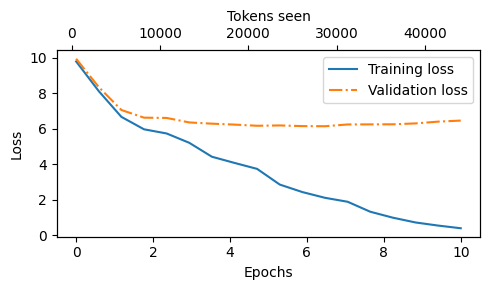

In [56]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # 专门用来控制坐标轴刻度的工具，这里用来强制 X 轴只显示整数刻度（因为 Epoch 是整数，不能有 0.5 个 Epoch）

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))  # 创建一个 5 英寸宽、3 英寸高的画布，这个尺寸是学术论文和技术报告的标准尺寸
                                             # ax1是底部的主坐标轴，用来显示「Epoch vs 损失」的关系
    # 绘制两条损失曲线（实线、点划线）
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # 只显示整数刻度（默认matplotlib会自动生成 0.5、1.5 这样的小数刻度，看起来非常不专业）

    # 创建第二个 X 轴（顶部坐标轴）
    ax2 = ax1.twiny()  # 创建一个共享Y轴的第二个X轴
    ax2.plot(tokens_seen, train_losses, alpha=0)  # 画一条完全透明的曲线
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # 自动调整布局，防止标签被画布边缘截断
    plt.savefig("loss-plot.pdf")  # 保存为PDF矢量图（无限放大不会模糊，非常适合插入论文、PPT 和技术报告。如果保存为 PNG，放大后会出现锯齿）
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)  # 调用函数，传入参数，生成损失图

- 从以上结果可以看出，模型在开始阶段生成的是难以理解的字符串，但是在后期能够生成基本符合语法的句子。
- 从训练集和验证集的损失值可以看出，模型开始出现过拟合现象。
- 如果检查后期它生成的某些段落，会发现它们与训练集中的内容完全相同(模型只是简单地记住了训练数据,背住答案罢了)。
- 之后的部分，我们将讨论一些解码策略，这些策略可以一定程度缓解这种“背答案”的问题。
- 请注意，这里的过拟合是由于训练集非常非常小，并且我们对其进行了多次迭代。
  - 本次 LLM 训练主要用于教学目的；我们的目标是观察模型是否能够学会生成连贯的文本。
  - 为了避免花费数周或数月时间在大量昂贵硬件上训练模型，我们将在后续加载预训练权重。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model-2.webp" width=350px>

**如果您对通过更高深的技术增强此训练函数感兴趣，例如学习率预热、余弦退火和梯度裁剪，请参阅[附录D](../../appendix-D/01_main-chapter-code)。**

**更大的数据集跟更深度的训练,可以在以下找到链接 [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)**

## 5.3 控制随机性的解码策略

- 对于像我们训练的这种规模相对较小的GPT模型（LLM），推理阶段的计算成本较低。因此，如果在训练时使用了GPU，推理阶段则无需依赖GPU资源。
- 我们可以利用第5章介绍的`generate_text_simple`函数（该函数已在简单训练函数中被调用）来逐步生成新文本，每次生成一个单词（或 token）。
- 正如5.1.2节所提到的，下一个生成的 token 是从词汇表中选取概率得分最高的 token 。

In [58]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
# greedy 解码是完全确定性的
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


- 即使我们多次调用 `generate_text_simple` 函数，大语言模型（LLM）生成的输出也始终是确定性的，即每次结果相同。
- 为了增强生成文本的灵活性，我们引入了两种解码策略来改进 `generate_text_simple`：**温度缩放** 和 **top-k 采样**。
- 这些方法能够调节模型生成文本的随机性和多样性，从而满足不同的应用需求。

### 5.3.1 温度缩放

- 在之前的实现中，我们始终使用 `torch.argmax` 来选择概率最高的 token 作为下一个生成的 token。
- 为了增加生成文本的多样性，我们可以改用 `torch.multinomial(probs, num_samples=1)`，从概率分布中随机采样下一个 token。
- 在这种方法中，每个索引被选中的概率与其在输入张量中对应的概率值成正比，从而实现基于概率的随机采样。

- 以下是对生成下一个 token 过程的简单回顾，假设我们使用一个非常小的词汇表来说明：

In [59]:
# 词表（Vocabulary），把每个词映射成一个唯一的整数 ID
vocab = {
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,}
# 反向词表，把 ID 映射回对应的词
inverse_vocab = {v: k for k, v in vocab.items()}
# 假设输入是 "every effort moves you"，模型返回的下一个token的logits
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
# 直接选概率最大的那个词，没有任何随机性
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [66]:
torch.manual_seed(123)
# Multinomial Sampling（多项式采样：按概率分布随机采样，概率高的词更容易被选中，但概率低的词也有机会）
next_token_id = torch.multinomial(probas, num_samples=1).item()  # 按probas的权重，随机选 1 个 token id
'''
这里虽然用了采样，但还是输出了forward，因为：
1.forward的概率是压倒性最高的，即使随机采样，它被选中的概率也远大于其他词。
2.我们固定了随机种子torch.manual_seed(123)，所以结果是可复现的。
如果把种子去掉，多跑几次，就有概率选到其他词（比如toward），这就是生成文本多样性的来源。
'''
print(inverse_vocab[next_token_id])

forward


- 我们不再依赖 `torch.argmax` 来选择最可能的 token ，而是通过 `torch.multinomial(probas, num_samples=1)` 从 softmax 分布中采样来确定下一个 token 。
- 为了直观地理解这一过程，我们可以使用原始的 softmax 概率对下一个 token 进行 1,000 次采样，并观察结果分布：

In [70]:
# 用 1000 次采样实验，直观验证torch.multinomial是否真的按 Softmax 概率分布来选择 token
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))  # torch.bincount是 PyTorch 里专门用来统计整数出现次数的工具
    # 把 id 映射回词
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


- 我们可以通过一种称为**温度缩放**的技术来调节概率分布和 token 选择的过程。
- 温度缩放的核心操作是将 logits 除以一个大于 0 的数值（即温度值），然后再应用 softmax 函数。
- 当温度值大于 1 时，softmax 输出的概率分布会更加均匀，从而增加生成文本的多样性。
- 当温度值小于 1 时，softmax 输出的概率分布会更加集中（更陡峭或更尖锐），从而倾向于选择概率更高的 token，减少随机性。

模型的预测概率往往过于自信或低估某些类别的概率，尤其在分类任务中。
温度缩放通过引入一个参数  T > 0  来重新调整 logits，改善预测概率的校准性能

In [71]:
# 温度校正函数
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

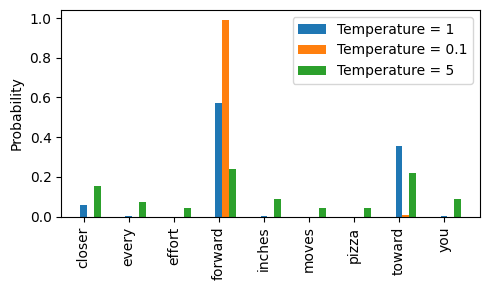

In [72]:
# 温度校正系数
temperatures = [1, 0.1, 5]  # 分别对应：原始分布、高置信度（低多样性）、低置信度（高多样性）
# 批量计算不同温度下的概率分布
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

# 画图
x = torch.arange(len(vocab))  # 为每个词创建一个位置索引（0~8，对应 9 个词），用来确定柱子的位置
bar_width = 0.15  # 设置单个柱子的宽度为 0.15，这样3个温度的柱子可以并排显示在同一个词的位置上，不会重叠

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):  # 遍历[1, 0.1, 5]三个温度值，i是索引，T是温度值
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

- 从结果中可以看出，当温度设置为 0.1 时，概率分布变得更加陡峭，接近于 `torch.argmax` 的行为，因此最可能的 token 几乎总是被选中：

In [73]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward


- 当温度设置为 5 时，概率分布变得更加均匀，从而增加了生成文本的多样性和随机性：

In [74]:
print_sampled_tokens(scaled_probas[2])

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


- 假设大语言模型（LLM）的输入是“every effort moves you”，上述方法有时可能会生成无意义的文本，例如“every effort moves you pizza”，其出现的概率为 3.2%（即在 1000 次采样中出现了 32 次）。

### 5.3.2 Top-k 取样

- 为了在使用更高温度增加输出多样性的同时减少生成无意义句子的概率，我们可以将采样限制在前 k 个最可能的 token 中：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/topk.webp" width=500px>

- （请注意，此图中的数值已截取到小数点后两位，以减少视觉干扰。Softmax 行中的值总和应为 1.0。）

- 我们可以按照下述建议补充代码

-	控制输出质量： 减少低概率、无意义的词被选中的机会。
-	保持多样性： 允许模型在概率较高的几个候选词中随机选择，而不是总是选择最高概率的词（这会导致输出缺乏变化）。

In [75]:
# Top-K 采样的作用是：只保留概率最高的前 K 个候选词，把其他所有词的概率直接置为 0，既保证多样性，又避免生成垃圾文本
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)  # torch.topk是 PyTorch 内置函数，专门用来提取张量中数值最大的 K 个元素
# next_token_logits：[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
print("Top logits:", top_logits)  # 前 3 个最高的 logits 值
print("Top positions:", top_pos)  # 这 3 个值在原始 logits 中的索引位置

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [76]:
# 屏蔽非 Top-K 的 logits
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],  # 判断每个 logits 是否小于前 K 个 logits 中最小的那个值，也就是4.51
    input=torch.tensor(float("-inf")),  # 条件为真时，返回input
    other=next_token_logits             # 条件为假时，返回other（原始 logits）
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


> NOTE:  
>
>  一种稍微更高效的实现方式可以通过以下代码实现：
>
> ```python
> new_logits = torch.full_like( # create tensor containing -inf values
>    next_token_logits, -torch.inf
>)   
> new_logits[top_pos] = next_token_logits[top_pos] # copy top k values into the -inf tensor
> ```
>
> For more details, see https://github.com/rasbt/LLMs-from-scratch/discussions/326


In [77]:
#  Softmax 归一化后，这 3 个词的概率会重新分配
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3 优化文本更新功能

- 在前两小节中，我们介绍了**温度采样**和**top-k 采样**的概念。
- 现在，我们将结合这两种方法，对之前用于生成大语言模型（LLM）文本的 `generate_simple` 函数进行改进，创建一个新的 `generate` 函数：

    - (译者):用自己的话总结下
    - 温度校正是更加平滑,防止数据差之毫厘以谬以千里 
    - topK是防止臭鱼烂虾进入筛选范围提高质量

In [78]:
# 一个工业级的融合了 Top-K 采样、温度缩放和 EOS提前终止 的文本生成函数，也是现在主流 LLM 解码的标准实现
'''
model	        训练好的 GPT 模型
idx	            输入 prompt 的 token id 序列，形状[batch_size, seq_len]
max_new_tokens	最多生成的新 token 数量
context_size	模型的最大上下文长度，超过会被截断
temperature	    温度系数，默认 0.0（等价于贪心解码）
top_k	        Top-K 采样的候选数，默认None（不启用）
eos_id	        结束符的 token id，遇到就提前终止生成
'''
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    # 自回归生成主循环
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]  # 只取最后context_size个token，防止超出模型上下文限制
        with torch.no_grad():
            logits = model(idx_cond)  # 模型前向传播，得到所有位置的logits
        logits = logits[:, -1, :]  # 只取最后一个位置的logits，预测下一个token

        # 核心优化 1：Top-K 采样
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)  # 提取前top_k个最高的logits值
            min_val = top_logits[:, -1]  # 找到这top_k个值中最小的那个，作为阈值
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)  # 把小于阈值的logits全部设为-inf，Softmax后概率为0
            # torch.where(条件, 满足时用的值, 不满足时用的值)
        # 核心优化 2：温度缩放 + 采样
        if temperature > 0.0:  # 启用采样模式，温度值越大，分布越平坦，随机性越强
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)  多项式采样：按概率分布随机选一个token （不是纯随机，是 “按概率加权的随机”）
        else:  # 如未启用采样，直接用argmax选概率最高的词，生成结果完全确定
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        # 核心优化 3：EOS 提前终止
        if idx_next == eos_id:  # 如果模型生成了结束符eos_id，就提前跳出循环，停止生成（避免模型一直生成无关内容）
            break

        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)
    return idx

In [79]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


## 5.4 在Pytorch中加载并保留权重

- 大模型的训练是很贵的, 所以导入已训练好的参数是很有必要的
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model-3.webp" width=400px>

- 在Pytorch中我们所推荐的保存方式是所谓的 `state_dict` ,通过调用 `torch.save` 的子模块 `.state_dict()` :

In [80]:
# 场景一: 只保存模型权重（推理用）
# model.state_dict()：保存模型的权重和偏置参数，不含任何训练相关的状态
# torch.save：        把权重保存为.pth文件，体积小、加载快
torch.save(model.state_dict(), "model.pth")

- 之后我们可以对新的 `GPTModel` 导入已经训练好的参数:

In [81]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 加载模型权重
model = GPTModel(GPT_CONFIG_124M)  # 必须先初始化模型：加载权重前，必须先创建一个和训练时结构完全相同的GPTModel实例，否则会报参数不匹配错误
model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))  # map_location=device：自动适配你的设备（CPU/GPU），避免设备不匹配报错
model.eval()  # 加载后直接切换到评估模式，用于推理生成文本                                      # weights_only=True：安全加载模式，防止恶意代码注入，是PyTorch官方推荐用法

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

- 自适应的Adam跟AdamW相较于SGD更好!
- 但是这些算法需要另外的参数, 所以保存训练好的参数就更有必要了:

In [82]:
# 场景二: 保存模型+优化器的完整状态（续训用）
'''
保存的不只是模型权重，还有优化器的状态（学习率、动量、梯度缓存等）。加载时，模型和优化器都能恢复到断点时的状态，训练可以无缝继续

optimizer.state_dict() = 优化器的内部状态
不是模型权重！它是优化器自己的 “私人记忆”，包括：
AdamW 的 动量（momentum）
AdamW 的 方差（variance）
当前的 学习率 lr
已经训练了多少步 step
→ 这是优化器的 “备忘录”，用来让你中断后继续训练，保持训练平滑不震荡
'''
torch.save({"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict()}, "model_and_optimizer.pth")  # 全家整整齐齐地保存

In [83]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)  # 保存检查点

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

model.train()  # 调整到训练模式

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [84]:
# 工业界最佳实践：实际项目中，通常会这样做：
# 训练过程中，每N轮保存一个断点
'''
epoch = 10
torch.save({"epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss},   f"checkpoint_epoch_{epoch}.pth")
'''

'\nepoch = 10\ntorch.save({"epoch": epoch,\n            "model_state_dict": model.state_dict(),\n            "optimizer_state_dict": optimizer.state_dict(),\n            "train_loss": train_loss,\n            "val_loss": val_loss},   f"checkpoint_epoch_{epoch}.pth")\n'

## 5.5 从OpenAI导入超参数

- 在之前的实验中，我们仅使用了一本非常短的小故事书来训练一个小型 GPT-2 模型，这主要是为了教学目的。
- 对此感兴趣的读者可以在[../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)中找到基于完整古登堡计划图书语料库的更长时间预训练记录。
- 幸运的是，我们无需花费数万到数十万美元在大型预训练语料库上预训练模型，而是可以直接加载 OpenAI 提供的预训练权重。

- 有关从Hugging Face中加载权重的另一种方法请参阅 [../02_alternative_weight_loading](../02_alternative_weight_loading)

- 首先，我们需要一些基础代码来从 OpenAI 下载文件并将权重加载到 Python 中。
- 由于 OpenAI 使用了 [TensorFlow](https://www.tensorflow.org/)，我们需要安装并使用 TensorFlow 来加载权重；同时，[tqdm](https://github.com/tqdm/tqdm) 是一个用于显示进度条的库。
- 取消注释并运行下一个代码单元以安装所需的库。

In [48]:
# pip install tensorflow tqdm

In [85]:
print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))
# tensorflow他到底还是来了

TensorFlow version: 2.21.0
tqdm version: 4.67.3


In [90]:
# 从当前文件夹的 gpt_download.py 文件进行相对导入 （这个函数是原书提供的工具函数，封装了文件下载、完整性校验、权重格式转换、本地缓存的全部逻辑）
from gpt_download import download_and_load_gpt2
# 加载GPT-2预训练权重
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")  # model_size="124M"：指定加载 1.24 亿参数的最小 GPT-2 模型（原书教学用）
                                                                                 # models_dir="gpt2"：指定模型文件的保存目录为当前目录下的gpt2文件夹

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


- 通过如下代码下载124M的模型:

In [93]:
# settings：字典，包含 GPT-2 模型的所有超参数（上下文长度、层数、注意力头数、嵌入维度等）
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [98]:
'''
键名	        全称	                        作用
blocks	    Transformer Blocks	        存储所有 12 层 Transformer 的权重，是一个列表，长度等于模型层数（124M 版是 12 层）
wte	        Word Token Embedding	    词嵌入层： 将词的 ID 映射为向量，    形状为 (词表大小, 嵌入维度)
wpe	        Word Position Embedding	    位置嵌入层：给每个位置的词加上位置信息，形状为 (最大上下文长度, 嵌入维度)
g / b	    LayerNorm Scale & Bias	    最终输出层的 LayerNorm 的缩放（gamma）和偏置（beta）参数
'''
# params：嵌套字典，包含 GPT-2 模型的全部预训练权重参数
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [108]:
print(params["wte"])
print("词嵌入层权重形状:", params["wte"].shape)
print("位置嵌入层权重形状:", params["wpe"].shape)
print(len(params["blocks"]))
print(params["b"].shape)
print(params["g"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
词嵌入层权重形状: (50257, 768)
位置嵌入层权重形状: (1024, 768)
12
(768,)
(768,)


- 此外，`model_size` 参数还支持 "355M"、"774M" 和 "1558M" 等选项。
- 下图总结了这些不同规模模型之间的主要差异：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/gpt-sizes.webp?timestamp=123" width=500px>

- 在上述操作中，我们已经成功将 124M 的 GPT-2 模型权重加载到 Python 中，但仍需将这些权重传输到我们的 `GPTModel` 实例中。
- 首先，我们需要初始化一个新的 `GPTModel` 实例。
- 需要注意的是，原始的 GPT 模型在多头注意力模块中为查询、键和值矩阵的线性层初始化了带有偏置向量的权重，这种做法既不必要也不推荐。然而，为了正确加载权重，我们在实现中必须将 `qkv_bias` 参数设置为 `True`。
- 此外，我们使用了原始 GPT-2 模型所支持的 `1024`  token 的上下文长度。

In [111]:
# 定义GPT-2各版本模型的核心配置字典，方便后续统一调用 （原书的基础配置GPT_CONFIG_124M是你自己实现的简化版本，而model_configs里的参数是 GPT-2 官方模型的真实配置）
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
# 选择要加载的GPT-2模型版本（这里以124M为例）
model_name = "gpt2-small (124M)"

NEW_CONFIG = GPT_CONFIG_124M.copy()                           # 复制基础配置（你之前定义的GPT_CONFIG_124M），避免修改原字典
NEW_CONFIG.update(model_configs[model_name])                  # 用选中模型的核心配置更新基础配置（嵌入维度、层数、注意力头数）
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True}) # 补充两个GPT-2官方模型特有的配置：上下文长度1024、QKV层启用偏置项


gpt = GPTModel(NEW_CONFIG)  # 使用最终配置初始化你自己实现的GPT模型
gpt.eval();  # 切换为评估模式（关闭Dropout、BatchNorm等训练用层）

- 接下来的任务是将 OpenAI 的权重分配到我们 `GPTModel` 实例中对应的权重张量中。

In [112]:
'''
辅助函数
1.调试神器：   形状校验是最重要的一步。只要有任何一个权重对应错了，它会立刻报错，告诉你哪一层、形状差多少，快速定位问题。
2.类型转换：   我们之前加载的params里的权重都是numpy.ndarray类型，而 PyTorch 模型的参数必须是torch.nn.Parameter类型才能被正确识别和使用。
3.自动设备迁移：转换为Parameter后，后续调用gpt.to(device)时，这些权重会自动移动到 GPU/CPU 上。
'''
def assign(left, right):
    # 严格的形状校验：如果形状不匹配，直接抛出错误
    if left.shape != right.shape:
        raise ValueError(f"形状不匹配！目标层形状: {left.shape}, 权重形状: {right.shape}")
    # 将numpy数组转换为PyTorch可训练的Parameter类型
    return torch.nn.Parameter(torch.tensor(right))

In [121]:
import numpy as np
# 按照GPT 模型的层级结构，从上到下、一层一层地把权重赋值进去
def load_weights_into_gpt(gpt, params):
    # 加载位置嵌入层 (Position Embedding)
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    # 加载词嵌入层 (Token Embedding)
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    # 循环加载每一个 Transformer 块
    for b in range(len(params["blocks"])):
        # 把OpenAI合并的QKV大矩阵，拆分成三个独立的Q、K、V矩阵 （OpenAI 为了节省计算，把 Q、K、V 三个线性层的权重 合并成了一个大矩阵c_attn.w存储）
        q_w, k_w, v_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        # 赋值给我们自己模型的三个独立线性层，注意这里必须转置！ （从 TensorFlow 来的线性层权重，必须转置之后才能赋值给 PyTorch 的层，否则形状会完全不匹配）
        gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight   = assign(gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        # 偏置项也是合并的，同样切成三等份
        q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        # 偏置是一维向量，不需要转置
        gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias   = assign(gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)
        # 加载自注意力层的输出投影 （对应 params 中的 'c_proj' (Concat Projection)）（线性层权重必须转置）
        gpt.trf_blocks[b].att.out_proj.weight = assign(gpt.trf_blocks[b].att.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias   = assign(gpt.trf_blocks[b].att.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])
        # 加载前馈网络 (FFN) 层 （c_fc(升维) → GELU → c_proj(降维)）
        gpt.trf_blocks[b].ff.layers[0].weight = assign(gpt.trf_blocks[b].ff.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias   = assign(gpt.trf_blocks[b].ff.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(gpt.trf_blocks[b].ff.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias   = assign(gpt.trf_blocks[b].ff.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])
        # 加载层归一化 (LayerNorm) 层 （每个 Transformer 块有两个层归一化：norm1(注意力前) 和norm2(前馈网络前) ）
        # g = gamma = scale，b = beta = shift （层归一化的参数是一维向量，不需要转置）
        gpt.trf_blocks[b].norm1.scale = assign(gpt.trf_blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(gpt.trf_blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(gpt.trf_blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(gpt.trf_blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])
    # 加载最终的全局层归一化 （所有Transformer块之后的最终层归一化，对应 params 顶层的 'g' 和 'b'）
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight  = assign(gpt.out_head.weight, params["wte"])  # 把out_head原来的随机权重扔掉，把tok_emb的预训练权重赋值给out_head
    print(gpt.out_head.weight is gpt.tok_emb.weight) #（这里只是复制，不是真正的共享）

load_weights_into_gpt(gpt, params)  # 调用函数
gpt.to(device); # 将整个模型（包括所有权重）移动到指定设备（GPU或CPU）


False


- 如果模型正确加载了,我们可以用先前的`generate` :

In [124]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("输出文本:\n", token_ids_to_text(token_ids, tokenizer))

输出文本:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?




- 我们可以确认模型权重已正确加载，因为模型能够生成连贯的文本；如果我们在加载过程中出现任何错误，模型将无法实现这一点。

- 如果您想了解另一种从 Hugging Face Hub 加载权重的方法，请参阅 [../02_alternative_weight_loading](../02_alternative_weight_loading)。

- 如果您对 GPT 架构与 Llama 架构（Meta AI 开发的一种流行大语言模型）之间的比较感兴趣，请查看附加内容：[../07_gpt_to_llama](../07_gpt_to_llama)。

## 总结与收获

- 请参考 [./gpt_train.py](./gpt_train.py) 脚本，这是一个独立的训练脚本。
- [./gpt_generate.py](./gpt_generate.py) 脚本会加载 OpenAI 提供的预训练权重，并根据提示生成文本。
- 您可以在 [./exercise-solutions.ipynb](./exercise-solutions.ipynb) 中找到练习的解答。